### Here we make plots of the training data vs validation data vs testing data

In [1]:
import torch
from Modules import pre_pro
from Modules.Neural_Net import Net
from Modules.Neural_Net import NetWrapper
from tqdm import tqdm
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc
import numpy as np
from torch.utils.data import DataLoader
import seaborn as sns
from Modules.beams import beam_trim



In [22]:
'training data'

data = torch.load('../../data/data.pt', weights_only=True)
frames = np.arange(1992, 1993, 1)
device = 'cuda'

beams = list(range(0,32))


frame = data[0]
trimmed = beam_trim(frame, beams)

print(trimmed.shape)



torch.Size([17504, 3])


In [23]:

with torch.no_grad():
    input, output = pre_pro.in_out(data, beams=beams, frames=frames)

dataset = pre_pro.FrameDataset(inputs_sorted=input, outputs_sorted= output)
spt_dataloader = DataLoader(dataset, pin_memory=True, num_workers=4, persistent_workers= True, batch_size=1)

'Take a batch_x and batch_y in dataloader'
print(len(dataset))



1


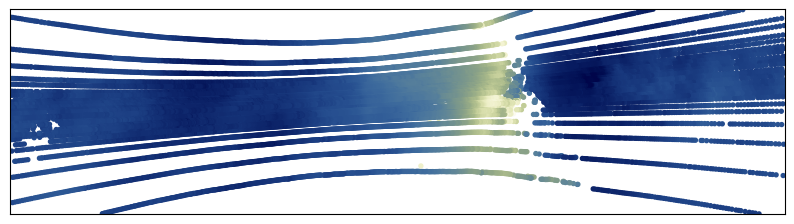

In [27]:

batch_x, batch_y = next(iter(spt_dataloader))

batch_x = batch_x.reshape(-1, 3)
batch_y = batch_y.reshape(-1, 1)


x = batch_x[:, 0].detach().numpy() 
y = batch_x[:, 1].detach().numpy()  
z = batch_y.detach().numpy().flatten()


fig, ax = plt.subplots(figsize=(10, 5))
plt.scatter(x, y, c=z, cmap=cmc.davos, vmin=0, vmax=6, s=8)
plt.xlim(-253, -132)
plt.ylim(-178, -146)
plt.xticks([])
plt.yticks([])
plt.gca().set_aspect('equal')


plt.show()


In [26]:
xyz = np.column_stack((x, y, z))
np.save('xyz.npy', xyz)